<a href="https://colab.research.google.com/github/cdiegor/OtimizacaoCombinatoria/blob/main/Pyomo_Introdu%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Introdução prática ao Pyomo (LP/MIP) — Notebook Didático
**Data:** 2025-12-03

Este caderno apresenta os conceitos básicos de modelagem com **Pyomo**:
- Criação de **variáveis** (escalares, vetores e por conjuntos)
- **Restrições** básicas e indexadas
- **Parâmetros** e **conjuntos**
- **Função objetivo**
- **Solução** com CBC/GLPK (quando disponíveis)
- Exemplos: um LP 2D, um plano de produção indexado e uma mochila 0–1

> Observação: Se um solver não estiver disponível no seu ambiente, o caderno seguirá até a construção do modelo e avisará na etapa de solução.


In [ ]:
!pip install pyomo
!apt-get install -y -qq glpk-utils
!apt-get install -y -qq coinor-cbc

In [ ]:

import math, random
from typing import Dict, List, Tuple
import numpy as np
import matplotlib.pyplot as plt

try:
    import pyomo.environ as pyo
except Exception as e:
    print("Pyomo não está instalado neste ambiente:", e)

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True
random.seed(42); np.random.seed(42)

def get_solver(max_seconds: int = 60):
    """Tenta CBC e GLPK; retorna (nome, objeto) ou (None, None)."""
    for name, optkey, timelit in [('cbc','seconds','seconds'), ('glpk','tmlim','tmlim')]:
        try:
            opt = pyo.SolverFactory(name)
            if opt.available():
                try:
                    opt.options[optkey] = int(max_seconds)
                except Exception:
                    pass
                return name, opt
        except Exception:
            pass
    print("Aviso: nenhum solver (cbc/glpk) parece disponível neste ambiente.")
    return None, None



## 1) Primeiro exemplo (LP 2D): variáveis escalares, restrições e objetivo

Problema (forma padrão de exemplo didático):
$
\max\; z = 3x + 2y\quad
\text{s.a.}\quad
\begin{cases}
5x + 3y \le 30\\
x + 2y \le 10\\
4x + 5y \le 30\\
x \ge 0,\; y \ge 0
\end{cases}
$

Vamos **construir** o modelo passo a passo e **resolver** (se houver solver).


In [ ]:

# Construção do modelo
model = pyo.ConcreteModel()

# Variáveis (escalares, contínuas, com limites inferiores)
model.x = pyo.Var(within=pyo.NonNegativeReals)
model.y = pyo.Var(within=pyo.NonNegativeReals)

# Restrições
model.c1 = pyo.Constraint(expr = 5*model.x + 3*model.y <= 30)
model.c2 = pyo.Constraint(expr = model.x + 2*model.y <= 10)
model.c3 = pyo.Constraint(expr = 4*model.x + 5*model.y <= 30)

# Objetivo (maximização)
model.obj = pyo.Objective(expr = 3*model.x + 2*model.y, sense=pyo.maximize)

print("Modelo construído.")
model.pprint()


Modelo construído.
2 Var Declarations
    x : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  None :  None : False :  True : NonNegativeReals
    y : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  None :  None : False :  True : NonNegativeReals

1 Objective Declarations
    obj : Size=1, Index=None, Active=True
        Key  : Active : Sense    : Expression
        None :   True : maximize : 3*x + 2*y

3 Constraint Declarations
    c1 : Size=1, Index=None, Active=True
        Key  : Lower : Body      : Upper : Active
        None :  -Inf : 5*x + 3*y :  30.0 :   True
    c2 : Size=1, Index=None, Active=True
        Key  : Lower : Body    : Upper : Active
        None :  -Inf : x + 2*y :  10.0 :   True
    c3 : Size=1, Index=None, Active=True
        Key  : Lower : Body      : Upper : Active
        None :  -Inf : 4*x + 5*y :  30.0 :   True

6 Declarations: x y c1 c2 c3 obj


In [ ]:

# Resolver (se possível) e imprimir solução
name, opt = get_solver(max_seconds=30)
results = None
if opt is not None:
    results = opt.solve(model, tee=False)
    print("Solver:", name, "| Status:", results.solver.status, "| TC:", results.solver.termination_condition)
else:
    print("Sem solver — pulando a solução.")

if results is None or str(results.solver.termination_condition).lower().find("optimal") == -1:
    print("Não foi possível confirmar otimalidade (ou sem solver). Ainda assim, as expressões foram montadas corretamente.")
else:
    print(f"x* = {pyo.value(model.x):.4f}, y* = {pyo.value(model.y):.4f}, z* = {pyo.value(model.obj):.4f}")


Solver: cbc | Status: ok | TC: optimal
x* = 4.6154, y* = 2.3077, z* = 18.4615



### Visualização do conjunto viável (2D)
Vamos **plotar** as retas limite e o polígono viável deste LP. Isso ajuda a conectar geometria com modelagem.


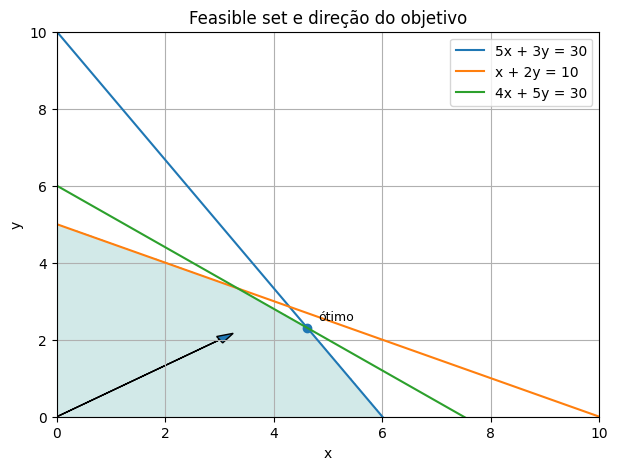

In [ ]:

# Grade para plot
xs = np.linspace(0, 10, 400)
c1_y = (30 - 5*xs)/3
c2_y = (10 - xs)/2
c3_y = (30 - 4*xs)/5

# Feasible region via preenchimento por malha
X, Y = np.meshgrid(xs, xs)
feasible = (5*X + 3*Y <= 30) & (X + 2*Y <= 10) & (4*X + 5*Y <= 30) & (X >= 0) & (Y >= 0)

plt.figure()
plt.plot(xs, c1_y, label="5x + 3y = 30")
plt.plot(xs, c2_y, label="x + 2y = 10")
plt.plot(xs, c3_y, label="4x + 5y = 30")
#plt.fill_between(X.ravel(), 0, 0, where=False)  # placeholder (mantém figura válida)

# contorno aproximado da região viável
plt.contourf(X, Y, feasible, levels=[0.5, 1], alpha=0.2)

# seta com direção do objetivo (gradiente)
plt.arrow(0, 0, 3, 2, head_width=0.2, head_length=0.3)

# solução, se houver
try:
    x_opt = pyo.value(model.x); y_opt = pyo.value(model.y)
    plt.scatter([x_opt],[y_opt])
    plt.text(x_opt+0.2, y_opt+0.2, "ótimo", fontsize=9)
except Exception:
    pass

plt.xlim(0, 10); plt.ylim(0, 10)
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.title("Feasible set e direção do objetivo")
plt.show()



## 2) Conjuntos, parâmetros e restrições indexadas (Plano de produção)

Exemplo clássico: decidir **quantidades** a produzir de cada produto $i \in I$ usando **recursos** $j \in J$.

- Variável: $x_i \ge 0$
- Lucro: $p_i$ → $\max \sum_i p_i x_i$
- Consumo de recurso: $a_{j i}$
- Disponibilidade: $b_j$ → $\sum_i a_{j i} x_i \le b_j,\; \forall j$


In [ ]:

# Dados do exemplo (pequenos para sala de aula)
I = ['A','B','C']   # produtos
J = ['R1','R2']     # recursos

p = {'A': 4.0, 'B': 3.0, 'C': 5.5}   # lucros
b = {'R1': 40.0, 'R2': 45.0}         # disponibilidades
a = {('R1','A'): 2.0, ('R1','B'): 1.0, ('R1','C'): 3.0,
     ('R2','A'): 1.0, ('R2','B'): 2.0, ('R2','C'): 1.0}

m2 = pyo.ConcreteModel()
m2.I = pyo.Set(initialize=I)
m2.J = pyo.Set(initialize=J)

m2.p = pyo.Param(m2.I, initialize=p)  # lucro
m2.b = pyo.Param(m2.J, initialize=b)  # recurso disponível
m2.a = pyo.Param(m2.J, m2.I, initialize=a, default=0.0)  # consumo

m2.x = pyo.Var(m2.I, within=pyo.NonNegativeReals)  # decisão indexada em I

def cap_rule(m, j):
    return sum(m.a[j,i]*m.x[i] for i in m.I) <= m.b[j]
m2.cap = pyo.Constraint(m2.J, rule=cap_rule)

m2.obj = pyo.Objective(expr=sum(m2.p[i]*m2.x[i] for i in m2.I), sense=pyo.maximize)

print("Modelo de produção construído.")
m2.pprint()

name2, opt2 = get_solver(30)
if opt2 is not None:
    res2 = opt2.solve(m2, tee=False)
    print("Solver:", name2, "| Status:", res2.solver.status, "| TC:", res2.solver.termination_condition)
    print("Solução:")
    for i in m2.I:
        print(f"x[{i}] = {pyo.value(m2.x[i]):.4f}")
    print(f"lucro = {pyo.value(m2.obj):.4f}")
else:
    print("Sem solver — pulando a solução.")


Modelo de produção construído.
2 Set Declarations
    I : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :    3 : {'A', 'B', 'C'}
    J : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :    2 : {'R1', 'R2'}

3 Param Declarations
    a : Size=6, Index=J*I, Domain=Any, Default=0.0, Mutable=False
        Key         : Value
        ('R1', 'A') :   2.0
        ('R1', 'B') :   1.0
        ('R1', 'C') :   3.0
        ('R2', 'A') :   1.0
        ('R2', 'B') :   2.0
        ('R2', 'C') :   1.0
    b : Size=2, Index=J, Domain=Any, Default=None, Mutable=False
        Key : Value
         R1 :  40.0
         R2 :  45.0
    p : Size=3, Index=I, Domain=Any, Default=None, Mutable=False
        Key : Value
          A :   4.0
          B :   3.0
          C :   5.5

1 Var Declarations
    x : Size=3, Index=I
        Key : Lower : Value : Upper : Fixed : Stale : Domai


### 2.1) `ConstraintList` e restrições geradas em laço

Às vezes, é útil construir restrições dinamicamente (por exemplo, adicionar cortes). O `ConstraintList`
permite **acrescentar** restrições após criar o modelo.


In [ ]:

m3 = pyo.ConcreteModel()
m3.x = pyo.Var(bounds=(0, None))
m3.y = pyo.Var(bounds=(0, None))
m3.obj = pyo.Objective(expr= 2*m3.x + 3*m3.y, sense=pyo.maximize)

m3.cons = pyo.ConstraintList()
# adicionando restrições em loop
for A, B, C in [(1,2,8), (3,1,9), (1,1,5)]:
    m3.cons.add(A*m3.x + B*m3.y <= C)

print("ConstraintList com", len(m3.cons), "restrições.")
m3.pprint()

name3, opt3 = get_solver(20)
if opt3 is not None:
    res3 = opt3.solve(m3, tee=False)
    print("Solver:", name3, "| Status:", res3.solver.status, "| TC:", res3.solver.termination_condition)
    print(f"x*={pyo.value(m3.x):.4f}, y*={pyo.value(m3.y):.4f}, z*={pyo.value(m3.obj):.4f}")
else:
    print("Sem solver — pulando a solução.")


ConstraintList com 3 restrições.
2 Var Declarations
    x : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  None :  None : False :  True :  Reals
    y : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  None :  None : False :  True :  Reals

1 Objective Declarations
    obj : Size=1, Index=None, Active=True
        Key  : Active : Sense    : Expression
        None :   True : maximize : 2*x + 3*y

1 Constraint Declarations
    cons : Size=3, Index={1, 2, 3}, Active=True
        Key : Lower : Body    : Upper : Active
          1 :  -Inf : x + 2*y :   8.0 :   True
          2 :  -Inf : 3*x + y :   9.0 :   True
          3 :  -Inf :   x + y :   5.0 :   True

4 Declarations: x y obj cons
Solver: cbc | Status: ok | TC: optimal
x*=2.0000, y*=3.0000, z*=13.0000



## 3) Exemplo inteiro (0–1): **Mochila**

Dados itens $i \in I$ com **peso** $w_i$ e **valor** $v_i$ e capacidade $W$.
- Variáveis binárias: $x_i \in \{0,1\}$
- Objetivo: $\max \sum_i v_i x_i$
- Restrição: $\sum_i w_i x_i \le W$


In [ ]:

items = ['a','b','c','d','e']
w = {'a':5,'b':3,'c':6,'d':2,'e':4}
v = {'a':8,'b':6,'c':9,'d':4,'e':7}
W = 12

knap = pyo.ConcreteModel()
knap.I = pyo.Set(initialize=items)
knap.w = pyo.Param(knap.I, initialize=w)
knap.v = pyo.Param(knap.I, initialize=v)

knap.x = pyo.Var(knap.I, within=pyo.Binary)

knap.cap = pyo.Constraint(expr=sum(knap.w[i]*knap.x[i] for i in knap.I) <= W)
knap.obj = pyo.Objective(expr=sum(knap.v[i]*knap.x[i] for i in knap.I), sense=pyo.maximize)

print("Mochila 0-1 construída.")
knap.pprint()

namek, optk = get_solver(30)
if optk is not None:
    resk = optk.solve(knap, tee=False)
    print("Solver:", namek, "| Status:", resk.solver.status, "| TC:", resk.solver.termination_condition)
    print("Solução:")
    for i in knap.I:
        print(f"x[{i}] = {int(round(pyo.value(knap.x[i]) or 0))}")
    print(f"valor = {pyo.value(knap.obj):.4f}")
else:
    print("Sem solver — pulando a solução.")


Mochila 0-1 construída.
1 Set Declarations
    I : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :    5 : {'a', 'b', 'c', 'd', 'e'}

2 Param Declarations
    v : Size=5, Index=I, Domain=Any, Default=None, Mutable=False
        Key : Value
          a :     8
          b :     6
          c :     9
          d :     4
          e :     7
    w : Size=5, Index=I, Domain=Any, Default=None, Mutable=False
        Key : Value
          a :     5
          b :     3
          c :     6
          d :     2
          e :     4

1 Var Declarations
    x : Size=5, Index=I
        Key : Lower : Value : Upper : Fixed : Stale : Domain
          a :     0 :  None :     1 : False :  True : Binary
          b :     0 :  None :     1 : False :  True : Binary
          c :     0 :  None :     1 : False :  True : Binary
          d :     0 :  None :     1 : False :  True : Binary
          e :     0 :  None :     1 : False :  True : Bina


## 4) Padrões de modelagem e API do Pyomo — em poucas linhas

- **Modelos**: `ConcreteModel()` (dados embutidos) e `AbstractModel()` (dados separados).
- **Conjuntos**: `Set()`, `RangeSet(n)`, `Set(initialize=lista)`.
- **Parâmetros**: `Param(index, initialize=..., default=...)`.
- **Variáveis**: `Var(index, within=Domain, bounds=(lb,ub))`. Domínios comuns: `Binary`, `Integers`, `NonNegativeReals`.
- **Restrições**: via `Constraint(index, rule=func)` ou `Constraint(expr=...)`.
- **Objetivo**: via `Objective(rule=func)` ou `Objective(expr=...)` e `sense=minimize/maximize`.
- **Inspeção**: `model.pprint()`, `value(expr)` após resolver.
- **Listas de restrições**: `ConstraintList()` para adicionar restrições dinamicamente.



## 5) Exercícios (para sua turma)

1. **LP 2D – Atividade guiada**: Modifique o primeiro LP para `max 5x + y` e acrescente a restrição `y ≤ 6`. Resolva e discuta a nova solução.
2. **Faixa para variáveis**: No modelo 2D, defina `x` com limite superior 6 (isto é, `0 ≤ x ≤ 6`). Como a solução muda?
3. **Parâmetros**: No plano de produção, multiplique todos os `p_i` por 1.15 e resolva novamente. Qual o impacto?
4. **Capacidades**: No plano de produção, reduza `b['R2']` de 45 para 30. Qual produto é mais afetado?
5. **Novos produtos**: Adicione um produto 'D' com `p=4.2`, `a[R1,D]=1.4`, `a[R2,D]=1.6` e re-solve.
6. **Mochila**: Inclua um item 'f' com `w=5`, `v=6` e verifique se ele entra na solução para `W=12` e para `W=14`.
7. **Inteiras vs. Reais**: Troque o domínio de `knap.x` para `NonNegativeReals` (relaxamento). Compare valor e interpretação.
8. **ConstraintList**: Na construção com `ConstraintList`, adicione `x ≤ 4` e `y ≤ 4`. Verifique a solução.
9. **RangeSet**: Refaça o plano de produção usando `RangeSet(3)` para `I` ao invés de lista explícita. Mapeie dados com dicionários.
10. **Cortes simples** (opcional): No LP 2D, force que `x + y ≤ 7` **apenas** se `x ≥ 3`. Dica: use `ConstraintList` e teste condições em Python antes de `add`.
